In [1]:
import hashlib
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT  = Path("C:/Users/Lenovo/Documents/TRADING-BOT")
DATA_FILE  = REPO_ROOT / "data" / "raw" / "BTCUSDT_M1.csv"
OUTPUT_DIR = REPO_ROOT / "research" / "experiments" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Frozen parameters (Exp 02A — NEVER change in this notebook) ───────────────
# Changes vs Exp 01: pullback_lookback, ema_tolerance_pct (new).
# SL/TP/exits IDENTICAL to Exp 01 — isolates signal change only (02A design).
FROZEN_PARAMS = {
    # Indicators (same as Exp 01)
    "ema_slow":             100,
    "ema_fast":             50,
    "stoch_k_period":       8,
    "stoch_d_smooth":       3,
    "stoch_signal_smooth":  3,
    "stoch_oversold":       20,
    "stoch_overbought":     80,
    # Exits — SAME as Exp 01 (isolate signal effect)
    "sl_pct":               0.00075,   # 0.075%
    "tp_pct":               0.0020,    # 0.20%
    "max_holding_candles":  30,
    # Session (same)
    "session_start_utc":    12,
    "session_end_utc":      16,
    # Costs (same)
    "taker_fee_per_side":   0.0004,
    "capital_usdt":         10_000,
    "risk_per_trade_pct":   0.005,
    # NEW in Exp 02A
    "pullback_lookback":    5,         # candles to detect oversold touch
    "ema_tolerance_pct":    0.0005,    # 0.05% — price max drop below EMA50 during pullback
}

SPEC_HASH = None  # computed in Cell 2

print("Cell 1 OK — Exp 02A: Momentum Continuation")
print(f"Output dir: {OUTPUT_DIR}")

Cell 1 OK — Exp 02A: Momentum Continuation
Output dir: C:\Users\Lenovo\Documents\TRADING-BOT\research\experiments\outputs


In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_FILE)
print(f"Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols")

# ── UTC enforcement ────────────────────────────────────────────────────────────
df_raw['open_time'] = pd.to_datetime(df_raw['open_time'], unit='ms', utc=True)

# ── SPEC_HASH ─────────────────────────────────────────────────────────────────
with open(DATA_FILE, 'rb') as _f:
    _dataset_sha256 = hashlib.sha256(_f.read()).hexdigest()

SPEC_HASH = hashlib.sha256(json.dumps({
    "spec_version":   "S4-r1",
    "experiment":     "02A-momentum-continuation",
    "dataset_file":   "BTCUSDT_M1.csv",
    "dataset_sha256": _dataset_sha256,
    "params":         FROZEN_PARAMS,
}, sort_keys=True).encode()).hexdigest()[:12]

print(f"Dataset SHA256 (prefix): {_dataset_sha256[:16]}...")
print(f"SPEC_HASH: {SPEC_HASH}")

# ── Sort & cast ────────────────────────────────────────────────────────────────
df_raw = df_raw.sort_values('open_time').reset_index(drop=True)
for col in ['open', 'high', 'low', 'close', 'volume']:
    df_raw[col] = df_raw[col].astype(float)

# ── Session filter: 12:00–16:00 UTC ───────────────────────────────────────────
mask = (
    (df_raw['open_time'].dt.hour >= FROZEN_PARAMS['session_start_utc']) &
    (df_raw['open_time'].dt.hour <  FROZEN_PARAMS['session_end_utc'])
)
df = df_raw[mask].copy().reset_index(drop=True)

print(f"\nFull dataset:              {len(df_raw):,} candles")
print(f"Session filtered (12-16 UTC): {len(df):,} candles")
print(f"Range: {df['open_time'].iloc[0]}  →  {df['open_time'].iloc[-1]}")

Loaded: 518,401 rows x 12 cols
Dataset SHA256 (prefix): bcec4ad427e5d1a0...
SPEC_HASH: 65d674ca66c2

Full dataset:              518,401 candles
Session filtered (12-16 UTC): 86,400 candles
Range: 2025-05-30 12:00:00+00:00  →  2026-05-24 15:59:00+00:00


In [3]:
# ── EMA 50 / 100 ──────────────────────────────────────────────────────────────
p = FROZEN_PARAMS

df['ema50']  = df['close'].ewm(span=p['ema_fast'], adjust=False).mean()
df['ema100'] = df['close'].ewm(span=p['ema_slow'], adjust=False).mean()

_warm = p['ema_slow'] * 3
sample = df.iloc[_warm:_warm + 4][['open_time', 'close', 'ema50', 'ema100']]
print(sample.to_string(index=False))
print("Cell 3 OK")

                open_time     close         ema50        ema100
2025-05-31 13:00:00+00:00 103991.39 104033.448652 104363.070712
2025-05-31 13:01:00+00:00 104026.08 104033.159685 104356.397629
2025-05-31 13:02:00+00:00 104057.51 104034.114600 104350.479062
2025-05-31 13:03:00+00:00 104127.28 104037.768145 104346.059278
Cell 3 OK


In [4]:
# ── Stochastic (8, 3, 3) ──────────────────────────────────────────────────────
k   = p['stoch_k_period']
d   = p['stoch_d_smooth']
sig = p['stoch_signal_smooth']

_ll    = df['low'].rolling(k).min()
_hh    = df['high'].rolling(k).max()
_range = (_hh - _ll).replace(0, np.nan)

_raw_k        = 100.0 * (df['close'] - _ll) / _range
df['stoch_k'] = _raw_k.rolling(d).mean()
df['stoch_d'] = df['stoch_k'].rolling(sig).mean()

print(f"NaN stoch_k: {df['stoch_k'].isna().sum()}  |  NaN stoch_d: {df['stoch_d'].isna().sum()}")
print(df[['open_time', 'close', 'stoch_k', 'stoch_d']].dropna().tail(3).to_string(index=False))
print("Cell 4 OK")

NaN stoch_k: 9  |  NaN stoch_d: 11
                open_time    close   stoch_k   stoch_d
2026-05-24 15:57:00+00:00 76387.56 11.981508 12.767321
2026-05-24 15:58:00+00:00 76362.79 11.552547 11.875381
2026-05-24 15:59:00+00:00 76371.59 12.245599 11.926551
Cell 4 OK


Spread spikes > 0.1%: 0 (0.00%)
Spread P80 median: 0.0050%


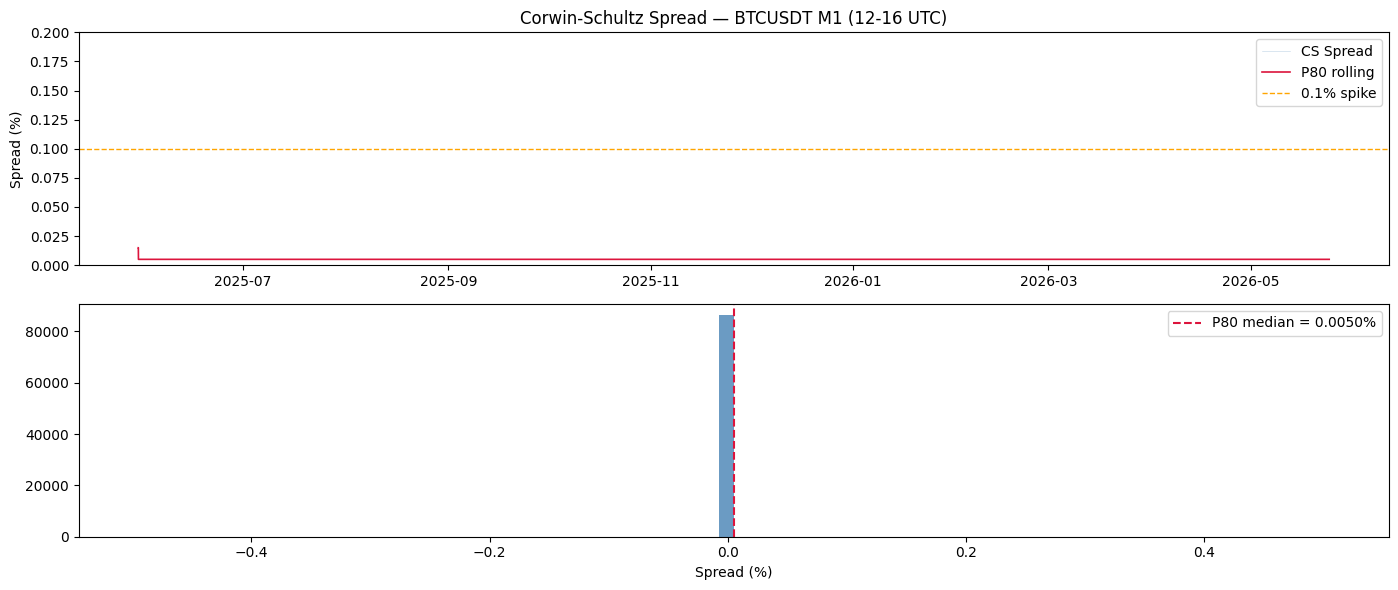

Saved: 02_spread_validation.png


In [5]:
# ── Corwin-Schultz Spread Estimator ───────────────────────────────────────────
CS_WINDOW = 240

def corwin_schultz_spread(high: pd.Series, low: pd.Series) -> pd.Series:
    beta  = np.log(high / low) ** 2
    _hi2  = pd.concat([high, high.shift(1)], axis=1).max(axis=1)
    _lo2  = pd.concat([low,  low.shift(1)],  axis=1).min(axis=1)
    gamma = np.log(_hi2 / _lo2) ** 2
    k1    = 3.0 - 2.0 * np.sqrt(2.0)
    alpha = (np.sqrt(2.0 * beta) - np.sqrt(beta)) / k1 - np.sqrt(gamma / k1)
    alpha = alpha.clip(lower=0.0)
    spread = 2.0 * (np.exp(alpha) - 1.0) / (1.0 + np.exp(alpha))
    return spread.clip(lower=0.00005)

df['spread_cs']  = corwin_schultz_spread(df['high'], df['low'])
df['spread_p80'] = (
    df['spread_cs']
    .rolling(CS_WINDOW, min_periods=10)
    .quantile(0.80)
    .fillna(0.00015)
)

n_spikes = (df['spread_cs'] > 0.001).sum()
print(f"Spread spikes > 0.1%: {n_spikes} ({n_spikes/len(df)*100:.2f}%)")
print(f"Spread P80 median: {df['spread_p80'].median()*100:.4f}%")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))
ax1.plot(df['open_time'], df['spread_cs'] * 100, alpha=0.35, lw=0.4,
         color='steelblue', label='CS Spread')
ax1.plot(df['open_time'], df['spread_p80'] * 100, color='crimson',
         lw=1.2, label='P80 rolling')
ax1.axhline(0.1, color='orange', ls='--', lw=1, label='0.1% spike')
ax1.set_ylim(0, 0.2); ax1.set_ylabel('Spread (%)'); ax1.legend()
ax1.set_title('Corwin-Schultz Spread — BTCUSDT M1 (12-16 UTC)')

ax2.hist(df['spread_cs'].clip(upper=0.001) * 100, bins=80,
         color='steelblue', edgecolor='none', alpha=0.8)
ax2.axvline(df['spread_p80'].median() * 100, color='crimson', ls='--',
            label=f"P80 median = {df['spread_p80'].median()*100:.4f}%")
ax2.set_xlabel('Spread (%)'); ax2.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_spread_validation.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: 02_spread_validation.png")

In [6]:
# ── Regime Tagging ────────────────────────────────────────────────────────────
# Same definitions as Exp 01 (consistency required for comparison).
REGIME_WINDOW = 240

df['atr_pct'] = (df['high'] - df['low']) / df['close']
_atr_p33 = df['atr_pct'].rolling(REGIME_WINDOW, min_periods=1).quantile(0.33)
_atr_p66 = df['atr_pct'].rolling(REGIME_WINDOW, min_periods=1).quantile(0.66)
df['volatility_regime'] = 'Medium'
df.loc[df['atr_pct'] < _atr_p33, 'volatility_regime'] = 'Low'
df.loc[df['atr_pct'] > _atr_p66, 'volatility_regime'] = 'High'

df['ema_spread_pct'] = (df['ema50'] - df['ema100']).abs() / df['close']
_esp_p80 = df['ema_spread_pct'].rolling(REGIME_WINDOW, min_periods=1).quantile(0.80)
df['trend_regime'] = 'Ranging'
df.loc[df['ema_spread_pct'] > _esp_p80, 'trend_regime'] = 'Trending'

pct_target = (
    ((df['volatility_regime'] == 'High') & (df['trend_regime'] == 'Trending')).mean() * 100
)
print(f"High Vol + Trending: {pct_target:.1f}% of session candles (regime gate target)")
print("\nFull distribution:")
print(df.groupby(['volatility_regime', 'trend_regime']).size()
      .div(len(df)).mul(100).round(1).to_string())
print("Cell 6 OK")

High Vol + Trending: 8.3% of session candles (regime gate target)

Full distribution:
volatility_regime  trend_regime
High               Ranging         27.2
                   Trending         8.3
Low                Ranging         26.7
                   Trending         6.2
Medium             Ranging         25.7
                   Trending         5.9
Cell 6 OK


In [7]:
# ── Signal Generation — Exp 02A: Momentum Continuation ────────────────────────
# Concept: in High Vol + Trending, enter when a SHALLOW pullback resets stoch
# and momentum reactivates (stoch rising). Price must have held above EMA50.
#
# Key diff vs Exp 01:
#   - Regime gate: only High Vol + Trending (entry blocked otherwise)
#   - Trigger: stoch reset + stoch rising (NOT K/D crossover)
#   - Shallow pullback guard: price stayed within ema_tolerance of EMA50
#
# Anti-leakage: signal on T, entry at T+1 open via .shift(1)

lb      = p['pullback_lookback']
ema_tol = p['ema_tolerance_pct']

# ── Regime gate ───────────────────────────────────────────────────────────────
regime_gate = (df['volatility_regime'] == 'High') & (df['trend_regime'] == 'Trending')

# ── Trend direction ───────────────────────────────────────────────────────────
trend_long  = (df['close'] > df['ema50']) & (df['close'] > df['ema100'])
trend_short = (df['close'] < df['ema50']) & (df['close'] < df['ema100'])

# ── Pullback detection ────────────────────────────────────────────────────────
# Stoch touched oversold/overbought within last `lb` candles
stoch_was_oversold   = df['stoch_k'].rolling(lb).min() < p['stoch_oversold']
stoch_was_overbought = df['stoch_k'].rolling(lb).max() > p['stoch_overbought']

# Stoch has now reset (left the extreme zone)
stoch_reset_up   = df['stoch_k'] > p['stoch_oversold']
stoch_reset_down = df['stoch_k'] < p['stoch_overbought']

# Momentum reactivating: stoch moving in trend direction
stoch_rising  = df['stoch_k'] > df['stoch_k'].shift(1)
stoch_falling = df['stoch_k'] < df['stoch_k'].shift(1)

# ── Shallow pullback guard ────────────────────────────────────────────────────
# Price didn't break more than ema_tolerance below EMA50 during pullback
price_held_long  = (
    df['low'].rolling(lb).min() > df['ema50'] * (1.0 - ema_tol)
)
price_held_short = (
    df['high'].rolling(lb).max() < df['ema50'] * (1.0 + ema_tol)
)

# ── Pullback depth feature (log for post-analysis, NOT a signal filter) ───────
df['pullback_stoch_min'] = df['stoch_k'].rolling(lb).min()
df['pullback_stoch_max'] = df['stoch_k'].rolling(lb).max()

# ── Combine ───────────────────────────────────────────────────────────────────
_long = (
    regime_gate        &
    trend_long         &
    stoch_was_oversold &
    stoch_reset_up     &
    stoch_rising       &
    price_held_long
)

_short = (
    regime_gate          &
    trend_short          &
    stoch_was_overbought &
    stoch_reset_down     &
    stoch_falling        &
    price_held_short
)

# Anti-leakage: shift(1)
df['signal_long']  = _long.shift(1).fillna(False)
df['signal_short'] = _short.shift(1).fillna(False)

n_long  = int(df['signal_long'].sum())
n_short = int(df['signal_short'].sum())
n_exp01 = 2169  # Exp 01 total signals for reference
print(f"LONG signals:  {n_long:,}")
print(f"SHORT signals: {n_short:,}")
print(f"Total:         {n_long + n_short:,}  (Exp 01 had {n_exp01:,} — regime gate should reduce this)")
print(f"Signal rate:   {(n_long + n_short) / len(df) * 100:.2f}% of session candles")
print("\nCell 7 OK — Exp 02A momentum continuation, regime gate active")

LONG signals:  352
SHORT signals: 374
Total:         726  (Exp 01 had 2,169 — regime gate should reduce this)
Signal rate:   0.84% of session candles

Cell 7 OK — Exp 02A momentum continuation, regime gate active


In [8]:
# ── Train / Hold-out split ─────────────────────────────────────────────────────
SPLIT_DATE = pd.Timestamp('2026-03-29', tz='UTC')

df['split'] = 'train'
df.loc[df['open_time'] >= SPLIT_DATE, 'split'] = 'holdout'

n_train   = (df['split'] == 'train').sum()
n_holdout = (df['split'] == 'holdout').sum()
print(f"Train candles:   {n_train:,}  ({n_train/(n_train+n_holdout)*100:.1f}%)")
print(f"Holdout candles: {n_holdout:,}  ({n_holdout/(n_train+n_holdout)*100:.1f}%)")
print(f"Train end:     {df[df['split']=='train']['open_time'].max()}")
print(f"Holdout start: {df[df['split']=='holdout']['open_time'].min()}")
print("Cell 8 OK")

Train candles:   72,720  (84.2%)
Holdout candles: 13,680  (15.8%)
Train end:     2026-03-28 15:59:00+00:00
Holdout start: 2026-03-29 12:00:00+00:00
Cell 8 OK


In [9]:
# ── Backtest ───────────────────────────────────────────────────────────────────
# Identical to Exp 01. SL/TP/costs/exit priority unchanged.
# pullback_stoch_min added to trade log for depth analysis.

def run_backtest(df: pd.DataFrame, params: dict, spec_hash: str) -> pd.DataFrame:
    p = params
    records = []

    opens    = df['open'].values
    highs    = df['high'].values
    lows     = df['low'].values
    closes   = df['close'].values
    times    = df['open_time'].values
    sig_l    = df['signal_long'].values
    sig_s    = df['signal_short'].values
    sp_p80   = df['spread_p80'].values
    ema50_v  = df['ema50'].values
    ema100_v = df['ema100'].values
    sk_v     = df['stoch_k'].values
    sd_v     = df['stoch_d'].values
    vol_reg  = df['volatility_regime'].values
    tr_reg   = df['trend_regime'].values
    splits   = df['split'].values
    pb_min_v = df['pullback_stoch_min'].values
    pb_max_v = df['pullback_stoch_max'].values

    in_pos = False; trade_id = 0
    direction = entry_price = sl_price = tp_price = entry_time = entry_date = None
    candles_held = 0; mae = mfe = 0.0
    spread_at_entry = ema50_at_entry = ema100_at_entry = 0.0
    stoch_k_at_entry = stoch_d_at_entry = 0.0
    vol_at_entry = tr_at_entry = split_at_entry = entry_month = ''
    pb_stoch_min_at_entry = pb_stoch_max_at_entry = 0.0

    for i in range(len(df)):
        t = pd.Timestamp(times[i])

        if in_pos:
            candles_held += 1
            h, l, c = highs[i], lows[i], closes[i]
            is_cross_day = (t.date() != entry_date)
            is_eod       = (t.hour == 15 and t.minute >= 59)

            if direction == 'LONG':
                adverse = (l - entry_price) / entry_price
                favorable = (h - entry_price) / entry_price
            else:
                adverse = (entry_price - h) / entry_price
                favorable = (entry_price - l) / entry_price
            mae = min(mae, adverse)
            mfe = max(mfe, favorable)

            exit_price = exit_reason = None
            if direction == 'LONG':
                if l <= sl_price:
                    exit_price, exit_reason = sl_price, 'SL'
                elif h >= tp_price:
                    exit_price, exit_reason = tp_price, 'TP'
                elif candles_held >= p['max_holding_candles']:
                    exit_price, exit_reason = c, 'MAX_HOLD'
                elif is_eod or is_cross_day:
                    exit_price, exit_reason = c, 'EOD'
            else:
                if h >= sl_price:
                    exit_price, exit_reason = sl_price, 'SL'
                elif l <= tp_price:
                    exit_price, exit_reason = tp_price, 'TP'
                elif candles_held >= p['max_holding_candles']:
                    exit_price, exit_reason = c, 'MAX_HOLD'
                elif is_eod or is_cross_day:
                    exit_price, exit_reason = c, 'EOD'

            if exit_price is not None:
                pnl_gross = ((exit_price - entry_price) / entry_price
                             if direction == 'LONG'
                             else (entry_price - exit_price) / entry_price)
                fees_pct   = p['taker_fee_per_side'] * 2.0
                cost_total = fees_pct + spread_at_entry

                records.append({
                    'trade_id':               trade_id,
                    'entry_time':             pd.Timestamp(entry_time),
                    'exit_time':              t,
                    'direction':              direction,
                    'entry_price':            float(entry_price),
                    'exit_price':             float(exit_price),
                    'exit_reason':            exit_reason,
                    'holding_candles':        candles_held,
                    'spread_pct':             float(spread_at_entry),
                    'fees_pct':               float(fees_pct),
                    'cost_total_pct':         float(cost_total),
                    'pnl_gross_pct':          float(pnl_gross),
                    'pnl_net_pct':            float(pnl_gross - cost_total),
                    'mae_pct':                float(abs(mae)),
                    'mfe_pct':                float(mfe),
                    'ema50_at_entry':         float(ema50_at_entry),
                    'ema100_at_entry':        float(ema100_at_entry),
                    'stoch_k_at_entry':       float(stoch_k_at_entry),
                    'stoch_d_at_entry':       float(stoch_d_at_entry),
                    'pullback_stoch_min':     float(pb_stoch_min_at_entry),
                    'pullback_stoch_max':     float(pb_stoch_max_at_entry),
                    'volatility_regime':      vol_at_entry,
                    'trend_regime':           tr_at_entry,
                    'split':                  split_at_entry,
                    'month':                  entry_month,
                    'spec_hash':              spec_hash,
                })
                in_pos = False; trade_id += 1

        else:
            if np.isnan(sk_v[i]) or np.isnan(sd_v[i]) or np.isnan(ema100_v[i]):
                continue
            direction_new = 'LONG' if sig_l[i] else ('SHORT' if sig_s[i] else None)
            if direction_new is not None:
                if t.hour == 15 and t.minute >= 59:
                    continue
                in_pos              = True
                direction           = direction_new
                entry_price         = opens[i]
                entry_time          = times[i]
                entry_date          = t.date()
                candles_held        = 0
                mae = mfe           = 0.0
                spread_at_entry     = float(sp_p80[i]) if not np.isnan(sp_p80[i]) else 0.00015
                ema50_at_entry      = float(ema50_v[i])
                ema100_at_entry     = float(ema100_v[i])
                stoch_k_at_entry    = float(sk_v[i])
                stoch_d_at_entry    = float(sd_v[i])
                pb_stoch_min_at_entry = float(pb_min_v[i]) if not np.isnan(pb_min_v[i]) else 0.0
                pb_stoch_max_at_entry = float(pb_max_v[i]) if not np.isnan(pb_max_v[i]) else 100.0
                vol_at_entry        = vol_reg[i]
                tr_at_entry         = tr_reg[i]
                split_at_entry      = splits[i]
                entry_month         = t.strftime('%Y-%m')
                if direction == 'LONG':
                    sl_price = entry_price * (1.0 - p['sl_pct'])
                    tp_price = entry_price * (1.0 + p['tp_pct'])
                else:
                    sl_price = entry_price * (1.0 + p['sl_pct'])
                    tp_price = entry_price * (1.0 - p['tp_pct'])

    return pd.DataFrame(records)


print("Running backtest...")
trades = run_backtest(df, FROZEN_PARAMS, SPEC_HASH)
print(f"Total trades: {len(trades):,}  (Exp 01 had 2,169 for reference)")
if len(trades):
    print(f"  Train:   {(trades['split']=='train').sum():,}")
    print(f"  Holdout: {(trades['split']=='holdout').sum():,}")
    print(f"\nExit distribution:")
    print(trades['exit_reason'].value_counts().to_string())
    print(f"\nDirection split:")
    print(trades['direction'].value_counts().to_string())
else:
    print("WARNING: 0 trades generated. Check signal logic and regime gate.")

Running backtest...
Total trades: 413  (Exp 01 had 2,169 for reference)
  Train:   353
  Holdout: 60

Exit distribution:
exit_reason
SL          263
TP          118
MAX_HOLD     25
EOD           7

Direction split:
direction
SHORT    218
LONG     195


In [10]:
# ── Equity Curve ───────────────────────────────────────────────────────────────
def compute_equity_curve(t: pd.DataFrame, capital: float) -> pd.DataFrame:
    t = t.sort_values('exit_time').copy().reset_index(drop=True)
    t['cumulative_pnl_pct']   = t['pnl_net_pct'].cumsum()
    t['equity_usdt']          = capital * (1.0 + t['cumulative_pnl_pct'])
    t['peak_equity']          = t['equity_usdt'].cummax()
    t['rolling_drawdown_pct'] = (t['equity_usdt'] - t['peak_equity']) / t['peak_equity'] * 100.0
    count, streak = [], 0
    for v in (t['equity_usdt'] < t['peak_equity']).values:
        streak = streak + 1 if v else 0
        count.append(streak)
    t['underwater_trades'] = count
    return t


if len(trades) == 0:
    print("No trades — skip equity curve"); equity_all = equity_train = equity_hold = pd.DataFrame()
else:
    equity_all   = compute_equity_curve(trades,                             FROZEN_PARAMS['capital_usdt'])
    equity_train = compute_equity_curve(trades[trades['split']=='train'],   FROZEN_PARAMS['capital_usdt'])
    equity_hold  = compute_equity_curve(trades[trades['split']=='holdout'], FROZEN_PARAMS['capital_usdt'])

    for label, eq in [('train', equity_train), ('holdout', equity_hold)]:
        if len(eq):
            print(f"{label:8s}  total_return={eq['cumulative_pnl_pct'].iloc[-1]*100:+.2f}%"
                  f"  max_dd={eq['rolling_drawdown_pct'].min():.2f}%"
                  f"  peak={eq['peak_equity'].max():.0f} USDT")

    equity_all.to_csv(OUTPUT_DIR / '02_equity.csv', index=False)
    print("\nSaved: outputs/02_equity.csv")

train     total_return=-25.32%  max_dd=-25.20%  peak=9984 USDT
holdout   total_return=-4.17%  max_dd=-4.02%  peak=9984 USDT

Saved: outputs/02_equity.csv


In [11]:
# ── Aggregate Metrics ─────────────────────────────────────────────────────────
def compute_expectancy(pnl: pd.Series) -> float:
    if len(pnl) == 0: return 0.0
    wins   = pnl[pnl > 0]
    losses = pnl[pnl <= 0]
    wr     = len(wins) / len(pnl)
    return wr * (wins.mean() if len(wins) else 0.0) - (1 - wr) * (losses.abs().mean() if len(losses) else 0.0)


def summary_metrics(t: pd.DataFrame, label: str) -> dict:
    if len(t) == 0: return {'split': label, 'n_trades': 0}
    pnl = t['pnl_net_pct']
    wins = pnl[pnl > 0]; loss = pnl[pnl <= 0]; wr = len(wins) / len(pnl)
    eq   = compute_equity_curve(t, FROZEN_PARAMS['capital_usdt'])
    return {
        'split':               label,
        'n_trades':            len(t),
        'win_rate':            round(wr, 4),
        'breakeven_wr':        0.618,
        'avg_win_net_pct':     round(wins.mean() * 100,       4) if len(wins) else 0.0,
        'avg_loss_net_pct':    round(loss.abs().mean() * 100, 4) if len(loss) else 0.0,
        'expectancy_net_pct':  round(compute_expectancy(pnl) * 100, 4),
        'total_return_pct':    round(pnl.sum() * 100, 2),
        'max_drawdown_pct':    round(eq['rolling_drawdown_pct'].min(), 2),
        'sharpe_ref':          round(pnl.mean() / pnl.std() if pnl.std() > 0 else 0.0, 3),
        'avg_mae_pct':         round(t['mae_pct'].mean() * 100, 4),
        'avg_mfe_pct':         round(t['mfe_pct'].mean() * 100, 4),
        'avg_holding_candles': round(t['holding_candles'].mean(), 1),
        'pct_tp':              round((t['exit_reason']=='TP').mean() * 100,       1),
        'pct_sl':              round((t['exit_reason']=='SL').mean() * 100,       1),
        'pct_max_hold':        round((t['exit_reason']=='MAX_HOLD').mean() * 100, 1),
        'pct_eod':             round((t['exit_reason']=='EOD').mean() * 100,      1),
        # New in Exp 02A: pullback depth stats
        'avg_pullback_stoch_min': round(t['pullback_stoch_min'].mean(), 2) if 'pullback_stoch_min' in t else None,
    }


train_metrics   = summary_metrics(trades[trades['split']=='train'],   'train')
holdout_metrics = summary_metrics(trades[trades['split']=='holdout'], 'holdout')

mdf = pd.DataFrame([train_metrics, holdout_metrics]).set_index('split').T
print(mdf.to_string())

# ── Per-month breakdown ───────────────────────────────────────────────────────
monthly_rows = []
for (split, month), g in trades.groupby(['split', 'month']):
    pnl = g['pnl_net_pct']
    monthly_rows.append({
        'split': split, 'month': month,
        'n_trades':         len(g),
        'win_rate':         round((pnl > 0).mean(), 3),
        'expectancy_pct':   round(compute_expectancy(pnl) * 100, 4),
        'total_return_pct': round(pnl.sum() * 100, 2),
    })
monthly = pd.DataFrame(monthly_rows).sort_values(['split', 'month']) if monthly_rows else pd.DataFrame()
print("\n── Per-month breakdown ──────────────────────────────────────────────")
print(monthly.to_string(index=False) if len(monthly) else "No trades to show")

# ── Pullback depth analysis ───────────────────────────────────────────────────
if 'pullback_stoch_min' in trades.columns and len(trades):
    print("\n── Pullback depth vs outcome ────────────────────────────────────────")
    trades['pb_depth_bucket'] = pd.cut(trades['pullback_stoch_min'],
                                        bins=[0, 5, 10, 15, 20], labels=['0-5','5-10','10-15','15-20'])
    pb_analysis = trades.groupby('pb_depth_bucket')['pnl_net_pct'].agg(
        n='count', wr=lambda x: (x > 0).mean(), e_net=lambda x: compute_expectancy(x) * 100
    ).round(4)
    print(pb_analysis.to_string())

split                      train  holdout
n_trades                353.0000  60.0000
win_rate                  0.3173   0.3167
breakeven_wr              0.6180   0.6180
avg_win_net_pct           0.1048   0.1150
avg_loss_net_pct          0.1538   0.1550
expectancy_net_pct       -0.0717  -0.0695
total_return_pct        -25.3200  -4.1700
max_drawdown_pct        -25.2000  -4.0200
sharpe_ref               -0.5820  -0.5430
avg_mae_pct               0.0937   0.1017
avg_mfe_pct               0.1175   0.1376
avg_holding_candles       6.8000   5.8000
pct_tp                   28.0000  31.7000
pct_sl                   63.5000  65.0000
pct_max_hold              6.8000   1.7000
pct_eod                   1.7000   1.7000
avg_pullback_stoch_min   29.2900  28.3300

── Per-month breakdown ──────────────────────────────────────────────
  split   month  n_trades  win_rate  expectancy_pct  total_return_pct
holdout 2026-03         1     0.000         -0.1600             -0.16
holdout 2026-04        30     0.3

In [12]:
# ── Block Bootstrap CI on E_net ───────────────────────────────────────────────
BOOTSTRAP_N     = 1000
BOOTSTRAP_BLOCK = 20

def block_bootstrap_expectancy(pnl: pd.Series, n_iter=BOOTSTRAP_N,
                                block_size=BOOTSTRAP_BLOCK, seed=42) -> tuple:
    rng = np.random.default_rng(seed)
    arr = pnl.values; n = len(arr)
    results = []
    for _ in range(n_iter):
        idx = []
        while len(idx) < n:
            start = int(rng.integers(0, max(1, n - block_size)))
            idx.extend(range(start, min(start + block_size, n)))
        results.append(compute_expectancy(pd.Series(arr[idx[:n]])))
    lo, hi = np.percentile(results, [2.5, 97.5])
    return lo, hi, np.array(results)


train_pnl   = trades[trades['split']=='train']['pnl_net_pct']
holdout_pnl = trades[trades['split']=='holdout']['pnl_net_pct']

if len(train_pnl) < 20 or len(holdout_pnl) < 20:
    print("WARNING: insufficient trades for reliable bootstrap — reporting point estimates only")
    ci_lo_hold = ci_hi_hold = compute_expectancy(holdout_pnl)
    _boot_hold = np.array([ci_lo_hold])
else:
    ci_lo_train, ci_hi_train, _ = block_bootstrap_expectancy(train_pnl)
    ci_lo_hold,  ci_hi_hold,  _boot_hold = block_bootstrap_expectancy(holdout_pnl)
    print(f"Train   E_net: {compute_expectancy(train_pnl)*100:+.4f}%   95% CI: [{ci_lo_train*100:.4f}%, {ci_hi_train*100:.4f}%]")

print(f"Holdout E_net: {compute_expectancy(holdout_pnl)*100:+.4f}%   95% CI: [{ci_lo_hold*100:.4f}%,  {ci_hi_hold*100:.4f}%]")
holdout_metrics['expectancy_ci_95_lo_pct'] = round(ci_lo_hold * 100, 4)
holdout_metrics['expectancy_ci_95_hi_pct'] = round(ci_hi_hold * 100, 4)
print("Cell 12 OK")

Train   E_net: -0.0717%   95% CI: [-0.0810%, -0.0588%]
Holdout E_net: -0.0695%   95% CI: [-0.0814%,  -0.0558%]
Cell 12 OK


In [13]:
# ── Direction-Aware Baseline Monte Carlo ──────────────────────────────────────
def direction_aware_baseline(df_full, train_trades, params, n_sims=1000, seed=42):
    rng        = np.random.default_rng(seed)
    p          = params
    n          = len(train_trades)
    if n == 0: return np.zeros(n_sims)
    long_ratio = (train_trades['direction'] == 'LONG').mean()
    sess       = df_full[df_full['split'] == 'train'].reset_index(drop=True)
    max_idx    = len(sess) - p['max_holding_candles'] - 2
    if max_idx <= 0: return np.zeros(n_sims)

    e_sims = []
    for _ in range(n_sims):
        entries    = rng.integers(0, max_idx, size=n)
        directions = rng.choice(['LONG', 'SHORT'], size=n, p=[long_ratio, 1 - long_ratio])
        pnl_sim    = []
        for idx, dirn in zip(entries, directions):
            ep   = sess['open'].iloc[idx]
            sp   = float(sess['spread_p80'].iloc[idx])
            if np.isnan(sp): sp = 0.00015
            cost = p['taker_fee_per_side'] * 2.0 + sp
            sl_p = ep * (1 - p['sl_pct']) if dirn == 'LONG' else ep * (1 + p['sl_pct'])
            tp_p = ep * (1 + p['tp_pct']) if dirn == 'LONG' else ep * (1 - p['tp_pct'])
            exit_pnl = None
            for k in range(1, p['max_holding_candles'] + 1):
                if idx + k >= len(sess): break
                h = sess['high'].iloc[idx + k]; l = sess['low'].iloc[idx + k]
                c = sess['close'].iloc[idx + k]; tk = sess['open_time'].iloc[idx + k]
                eod = (tk.hour == 15 and tk.minute >= 59)
                if dirn == 'LONG':
                    if l <= sl_p: exit_pnl = (sl_p-ep)/ep - cost; break
                    elif h >= tp_p: exit_pnl = (tp_p-ep)/ep - cost; break
                    elif k == p['max_holding_candles'] or eod: exit_pnl = (c-ep)/ep - cost; break
                else:
                    if h >= sl_p: exit_pnl = (ep-sl_p)/ep - cost; break
                    elif l <= tp_p: exit_pnl = (ep-tp_p)/ep - cost; break
                    elif k == p['max_holding_candles'] or eod: exit_pnl = (ep-c)/ep - cost; break
            pnl_sim.append(exit_pnl if exit_pnl is not None else -cost)
        e_sims.append(compute_expectancy(pd.Series(pnl_sim)))
    return np.array(e_sims)


print("Running direction-aware baseline (1000 sims)... ~60-120s")
baseline_dist  = direction_aware_baseline(df, trades[trades['split']=='train'], FROZEN_PARAMS)
baseline_p95   = float(np.percentile(baseline_dist, 95))
strategy_e_net = compute_expectancy(holdout_pnl)

print(f"Baseline P95:          {baseline_p95*100:+.4f}%")
print(f"Strategy E_net (hold): {strategy_e_net*100:+.4f}%")
print(f"Strategy > P95:        {strategy_e_net > baseline_p95}")

np.savetxt(OUTPUT_DIR / '02_baseline_dist.csv', baseline_dist * 100,
           delimiter=',', header='baseline_e_net_pct', comments='')
print("Saved: outputs/02_baseline_dist.csv")

Running direction-aware baseline (1000 sims)... ~60-120s
Baseline P95:          -0.0676%
Strategy E_net (hold): -0.0695%
Strategy > P95:        False
Saved: outputs/02_baseline_dist.csv


In [14]:
# ── Regime Breakdown ──────────────────────────────────────────────────────────
# Note: all Exp 02A trades are already in High Vol + Trending (regime gate).
# This breakdown confirms and checks for sub-regime variance within that filter.
regime_rows = []
for (split, vol, trend), g in trades.groupby(['split', 'volatility_regime', 'trend_regime']):
    pnl = g['pnl_net_pct']
    regime_rows.append({
        'split': split, 'volatility_regime': vol, 'trend_regime': trend,
        'n_trades':         len(g),
        'win_rate':         round((pnl > 0).mean(), 3),
        'expectancy_pct':   round(compute_expectancy(pnl) * 100, 4),
        'total_return_pct': round(pnl.sum() * 100, 2),
    })
regime_df = pd.DataFrame(regime_rows) if regime_rows else pd.DataFrame()
print("E_net by regime (should be mostly High+Trending given gate):")
print(regime_df.to_string(index=False) if len(regime_df) else "No trades")

E_net by regime (should be mostly High+Trending given gate):
  split volatility_regime trend_regime  n_trades  win_rate  expectancy_pct  total_return_pct
holdout              High      Ranging         1     0.000         -0.1600             -0.16
holdout              High     Trending        32     0.375         -0.0569             -1.82
holdout               Low     Trending         9     0.333         -0.0559             -0.50
holdout            Medium      Ranging         1     0.000         -0.0676             -0.07
holdout            Medium     Trending        17     0.235         -0.0953             -1.62
  train              High      Ranging         2     0.000         -0.1600             -0.32
  train              High     Trending       198     0.379         -0.0565            -11.19
  train               Low      Ranging         3     0.333         -0.0460             -0.14
  train               Low     Trending        46     0.196         -0.0915             -4.21
  train  

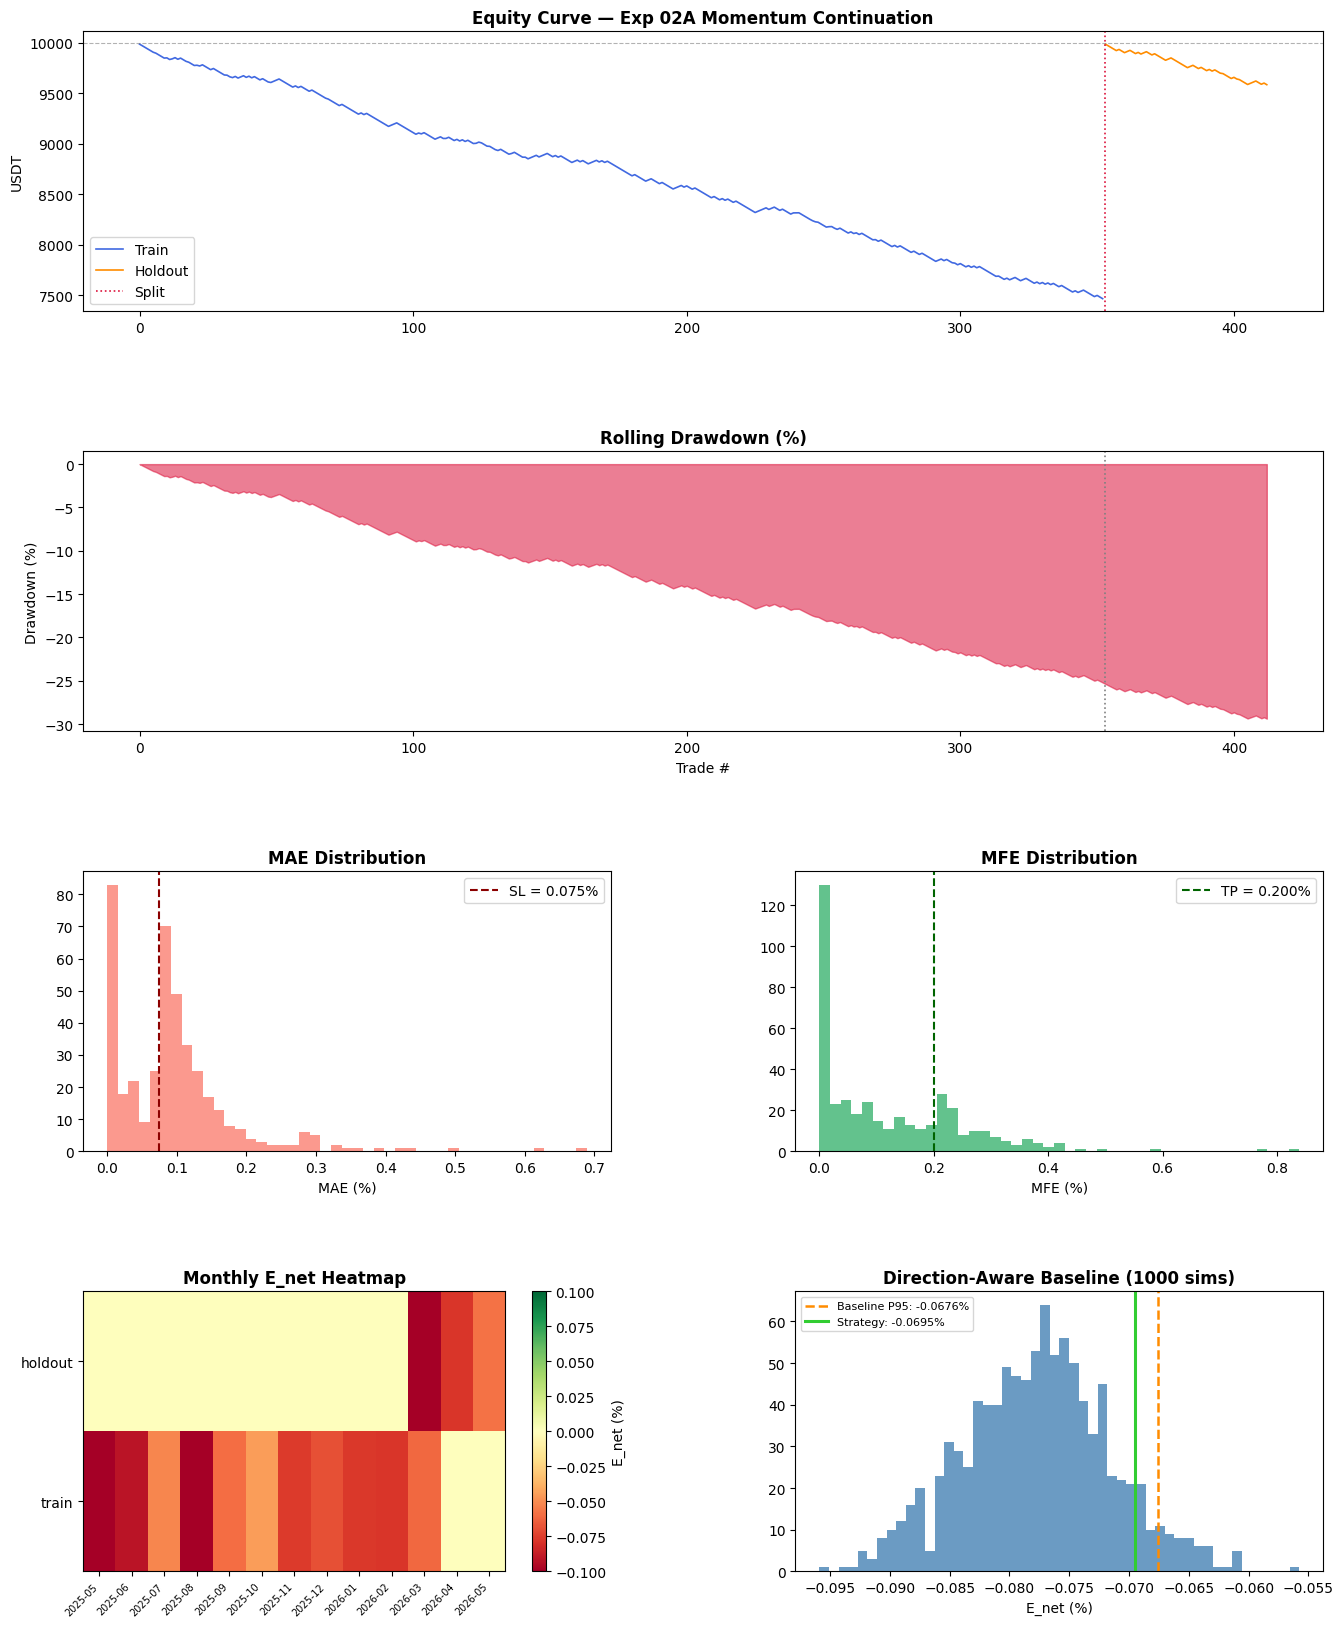

Saved: outputs/02_visualizations.png


In [15]:
# ── Visualizations ─────────────────────────────────────────────────────────────
if len(equity_all) == 0:
    print("No trades — skip visualizations");
else:
    fig = plt.figure(figsize=(16, 20))
    gs  = GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.35)

    ax1 = fig.add_subplot(gs[0, :])
    if len(equity_train):
        ax1.plot(range(len(equity_train)), equity_train['equity_usdt'],
                 color='royalblue', lw=1.2, label='Train')
    if len(equity_hold):
        ax1.plot(range(len(equity_train), len(equity_train)+len(equity_hold)),
                 equity_hold['equity_usdt'], color='darkorange', lw=1.2, label='Holdout')
    ax1.axhline(FROZEN_PARAMS['capital_usdt'], color='gray', ls='--', lw=0.8, alpha=0.6)
    ax1.axvline(len(equity_train), color='crimson', ls=':', lw=1.2, label='Split')
    ax1.set_title('Equity Curve — Exp 02A Momentum Continuation', fontweight='bold')
    ax1.set_ylabel('USDT'); ax1.legend()

    ax2 = fig.add_subplot(gs[1, :])
    ax2.fill_between(range(len(equity_all)), equity_all['rolling_drawdown_pct'], 0,
                     alpha=0.55, color='crimson')
    ax2.axvline(len(equity_train), color='gray', ls=':', lw=1.2)
    ax2.set_title('Rolling Drawdown (%)', fontweight='bold')
    ax2.set_ylabel('Drawdown (%)'); ax2.set_xlabel('Trade #')

    ax3 = fig.add_subplot(gs[2, 0])
    ax3.hist(trades['mae_pct'] * 100, bins=45, color='salmon', edgecolor='none', alpha=0.8)
    ax3.axvline(FROZEN_PARAMS['sl_pct'] * 100, color='darkred', ls='--', lw=1.5,
                label=f"SL = {FROZEN_PARAMS['sl_pct']*100:.3f}%")
    ax3.set_title('MAE Distribution', fontweight='bold'); ax3.set_xlabel('MAE (%)'); ax3.legend()

    ax4 = fig.add_subplot(gs[2, 1])
    ax4.hist(trades['mfe_pct'] * 100, bins=45, color='mediumseagreen', edgecolor='none', alpha=0.8)
    ax4.axvline(FROZEN_PARAMS['tp_pct'] * 100, color='darkgreen', ls='--', lw=1.5,
                label=f"TP = {FROZEN_PARAMS['tp_pct']*100:.3f}%")
    ax4.set_title('MFE Distribution', fontweight='bold'); ax4.set_xlabel('MFE (%)'); ax4.legend()

    ax5 = fig.add_subplot(gs[3, 0])
    if len(monthly) > 0:
        try:
            mp = monthly.pivot(index='split', columns='month', values='expectancy_pct').fillna(0)
            im = ax5.imshow(mp.values, aspect='auto', cmap='RdYlGn', vmin=-0.1, vmax=0.1)
            ax5.set_xticks(range(len(mp.columns)))
            ax5.set_xticklabels(mp.columns, rotation=45, ha='right', fontsize=7)
            ax5.set_yticks(range(len(mp.index)))
            ax5.set_yticklabels(mp.index)
            plt.colorbar(im, ax=ax5, label='E_net (%)')
        except Exception as e:
            ax5.text(0.5, 0.5, str(e), ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title('Monthly E_net Heatmap', fontweight='bold')

    ax6 = fig.add_subplot(gs[3, 1])
    ax6.hist(baseline_dist * 100, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    ax6.axvline(baseline_p95 * 100, color='darkorange', ls='--', lw=1.8,
                label=f'Baseline P95: {baseline_p95*100:.4f}%')
    ax6.axvline(strategy_e_net * 100, color='limegreen', ls='-', lw=2.2,
                label=f'Strategy: {strategy_e_net*100:.4f}%')
    ax6.set_title('Direction-Aware Baseline (1000 sims)', fontweight='bold')
    ax6.set_xlabel('E_net (%)'); ax6.legend(fontsize=8)

    plt.savefig(OUTPUT_DIR / '02_visualizations.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved: outputs/02_visualizations.png")

In [16]:
# ── Go / No-Go Decision Table ──────────────────────────────────────────────────
e_net_hold = compute_expectancy(holdout_pnl)
n_hold     = len(trades[trades['split']=='holdout'])
ci_lo      = holdout_metrics.get('expectancy_ci_95_lo_pct', 0) / 100

required = {
    'E_net > 0':                      e_net_hold > 0,
    'n_trades >= 100':                n_hold >= 100,
    'CI_95_lower > -0.02%':           ci_lo > -0.0002,
    'strategy_E_net > baseline_P95':  strategy_e_net > baseline_p95,
}

e_train_val = compute_expectancy(train_pnl)
_holdout_monthly = monthly[monthly['split'] == 'holdout'] if len(monthly) else pd.DataFrame()
advisory = {
    'train->holdout degradation < 50%': (
        abs(e_train_val - e_net_hold) / abs(e_train_val) < 0.5
        if abs(e_train_val) > 1e-9 else False
    ),
    'monthly E_net positive >= 6/12 (holdout only)': (
        int((_holdout_monthly['expectancy_pct'] > 0).sum()) >= 6
        if len(_holdout_monthly) > 0 else False
    ),
    'max_drawdown < 20%': (
        equity_all['rolling_drawdown_pct'].min() > -20.0 if len(equity_all) else False
    ),
    'win_rate > 55%': (
        (trades['pnl_net_pct'] > 0).mean() > 0.55 if len(trades) else False
    ),
}

all_pass = all(required.values())
verdict  = 'GO' if all_pass else 'NO-GO'

# n_trades note: regime gate reduces volume — flag if holdout < 100 but train OK
n_train_trades = len(trades[trades['split']=='train'])
low_volume_note = (n_hold < 100 and n_train_trades >= 100)

SEP = '=' * 60
print(SEP)
print(f"  EXPERIMENT 02A — MOMENTUM CONTINUATION (High Vol+Trending)")
print(f"  SPEC_HASH : {SPEC_HASH}")
print(f"  VERDICT   : {verdict}  {'(ALL required pass)' if all_pass else '(some required FAIL)'}")
if low_volume_note:
    print(f"  NOTE: holdout n={n_hold} < 100 (regime gate reduces volume). Train had {n_train_trades} trades.")
print(SEP)
print("\n  Required (all must pass):")
for k, v in required.items():
    print(f"    {'PASS' if v else 'FAIL'}  {k}")
print("\n  Advisory (informational):")
for k, v in advisory.items():
    print(f"    {'OK  ' if v else 'WARN'}  {k}")
print(SEP)

# ── Save artifacts ────────────────────────────────────────────────────────────
if len(trades):
    trades.to_csv(OUTPUT_DIR / '02_trades.csv', index=False)

metrics_out = {
    'spec_hash': SPEC_HASH, 'verdict': verdict,
    'train': train_metrics, 'holdout': holdout_metrics,
    'required_checks': {k: bool(v) for k, v in required.items()},
    'advisory_checks': {k: bool(v) for k, v in advisory.items()},
}
with open(OUTPUT_DIR / '02_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_out, f, indent=2, default=str)

print("\n  Artifacts:")
for fname in ['02_trades.csv', '02_equity.csv', '02_metrics.json',
              '02_baseline_dist.csv', '02_spread_validation.png', '02_visualizations.png']:
    path = OUTPUT_DIR / fname
    size = path.stat().st_size if path.exists() else 0
    print(f"    {fname}  ({size:,} bytes)" if size else f"    {fname}  (pending/skipped)")

  EXPERIMENT 02A — MOMENTUM CONTINUATION (High Vol+Trending)
  SPEC_HASH : 65d674ca66c2
  VERDICT   : NO-GO  (some required FAIL)
  NOTE: holdout n=60 < 100 (regime gate reduces volume). Train had 353 trades.

  Required (all must pass):
    FAIL  E_net > 0
    FAIL  n_trades >= 100
    FAIL  CI_95_lower > -0.02%
    FAIL  strategy_E_net > baseline_P95

  Advisory (informational):
    OK    train->holdout degradation < 50%
    WARN  monthly E_net positive >= 6/12 (holdout only)
    WARN  max_drawdown < 20%
    WARN  win_rate > 55%

  Artifacts:
    02_trades.csv  (144,865 bytes)
    02_equity.csv  (171,968 bytes)
    02_metrics.json  (1,559 bytes)
    02_baseline_dist.csv  (27,020 bytes)
    02_spread_validation.png  (48,480 bytes)
    02_visualizations.png  (166,301 bytes)
